# Predicting Insurance Claim Amounts
## Objective
Estimate medical insurance charges based on personal attributes using Linear Regression.
## Dataset
Medical Cost Personal Dataset

Target variable: charges
Common features:
age, sex, bmi, children, smoker, region, charges (target)

## Load & Inspect Dataset

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Cleaning (Minimal for this dataset)

In [19]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

This dataset has no missing values

## Encode Categorical Variables
### Label Encode binary columns

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])


### One-Hot Encode region

In [21]:
df = pd.get_dummies(df, columns=["region"], drop_first=True)


## Feature Correlation Analysis

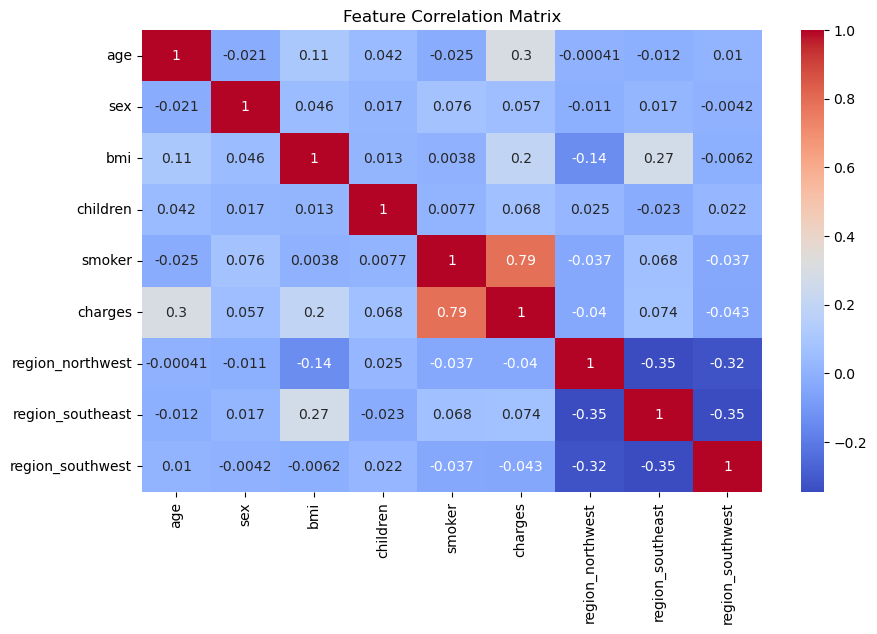

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


Key observation to mention:
Smoking status and BMI show strong correlation with charges

## Visualization: Impact on Insurance Charges
### BMI vs Charges

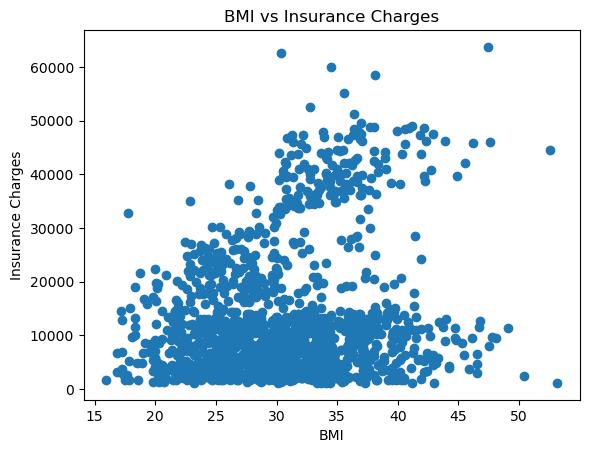

In [23]:
plt.scatter(df["bmi"], df["charges"])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()


### Age vs Charges

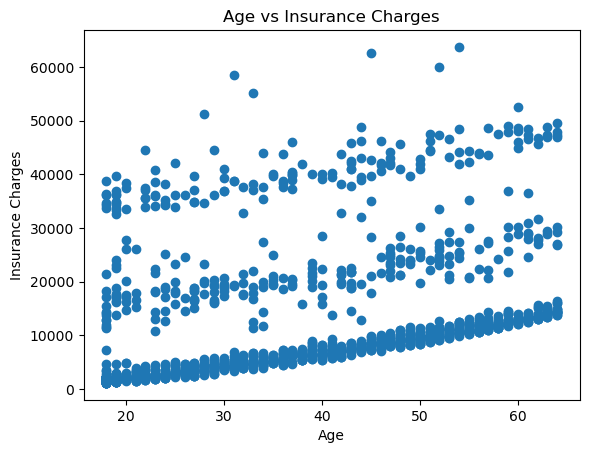

In [24]:
plt.scatter(df["age"], df["charges"])
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.show()


### Smoker vs Charges

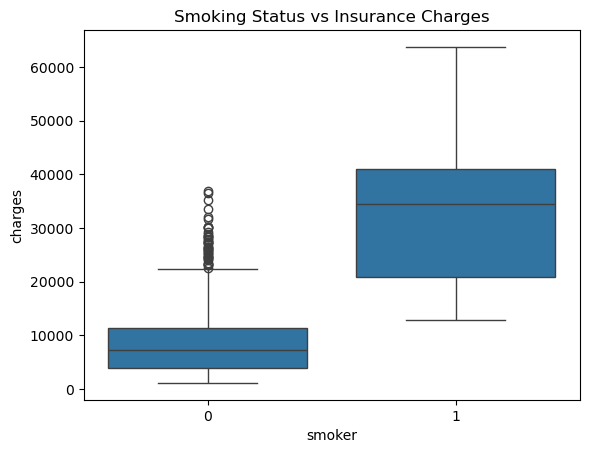

In [25]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoking Status vs Insurance Charges")
plt.show()


## Train Linear Regression Model

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Evaluation (MAE & RMSE)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 4181.194473753648
RMSE: 5796.284659276273


Eplaination:

MAE: Average absolute prediction error

RMSE: Penalizes large errors more heavily

## Feature Importance (Linear Regression Coefficients)

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

feature_importance


,Feature,Coefficient
4,smoker,23651.128856
3,children,425.278784
2,bmi,337.092552
0,age,256.975706
1,sex,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


Highlight:

Smoker has the highest positive impact

BMI and age significantly increase insurance costs

## Final Conclusion

A linear regression model was successfully developed to predict medical insurance claim amounts. Exploratory analysis revealed that smoking status, BMI, and age have a strong influence on insurance charges. Model evaluation using MAE and RMSE demonstrated reasonable prediction accuracy. The results indicate that smokers incur substantially higher medical costs, while increased BMI and age also contribute significantly to higher insurance charges.

Skills Demonstrated:

* Regression Modeling
* Feature correlation & visualization
* MAE & RMSE evaluation
* Real-world interpretation
